In [4]:
#importing the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import string, os
import nltk
import re
import keras
import random
import io
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adamax
import sys
from PIL import Image
import warnings
warnings.filterwarnings("ignore")


In [6]:
data = pd.read_csv("/content/Songs.csv")
data.head()

,Artist,Title,Lyrics
0,Taylor Swift,cardigan,"Vintage tee, brand new phone\nHigh heels on co..."
1,Taylor Swift,exile,"I can see you standing, honey\nWith his arms a..."
2,Taylor Swift,Lover,We could leave the Christmas lights up 'til Ja...
3,Taylor Swift,the 1,"I'm doing good, I'm on some new shit\nBeen say..."
4,Taylor Swift,Look What You Made Me Do,I don't like your little games\nDon't like you...


In [7]:
#Printing the names of artists in the lyrics data
print("Artists in the data:\n",data.Artist.value_counts())

Artists in the data:
 Artist
Taylor Swift          50
Billie Eilish         50
David Bowie           50
Billy Joel            50
Eric Clapton          50
Leonard Cohen         50
Bruce Springsteen     40
The Beatles           35
Vance Joy             30
Bryan Adams           30
Lana Del Rey          30
Nat King Cole         30
​twenty one pilots    30
Elton John            30
Ray LaMontagne        30
John Denver           30
Frank Sinatra         30
George Michael        30
Queen                 30
Ed Sheeran            20
Bob Dylan             20
Name: count, dtype: int64


In [8]:
#Printing the size of dataset
print("Size of Dataset:",data.shape)

Size of Dataset: (745, 3)


In [9]:
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [10]:
#Adding a column of numbers of Characters,words and sentences in each msg
data["No_of_Characters"] = data["Lyrics"].apply(len)
data["No_of_Words"] = data["Lyrics"].apply(lambda x: len(x.split()))
data["No_of_Lines"] = data["Lyrics"].str.split('\n').apply(len)
data.describe()

,No_of_Characters,No_of_Words,No_of_Lines
count,745.000000,745.000000,745.000000
mean,1403.347651,276.260403,46.277852
std,666.721467,129.230505,21.180531
min,1.000000,1.000000,1.000000
25%,946.000000,189.000000,33.000000
50%,1289.000000,255.000000,44.000000
75%,1714.000000,340.000000,56.000000
max,7267.000000,1386.000000,224.000000


<Figure size 1500x1500 with 0 Axes>

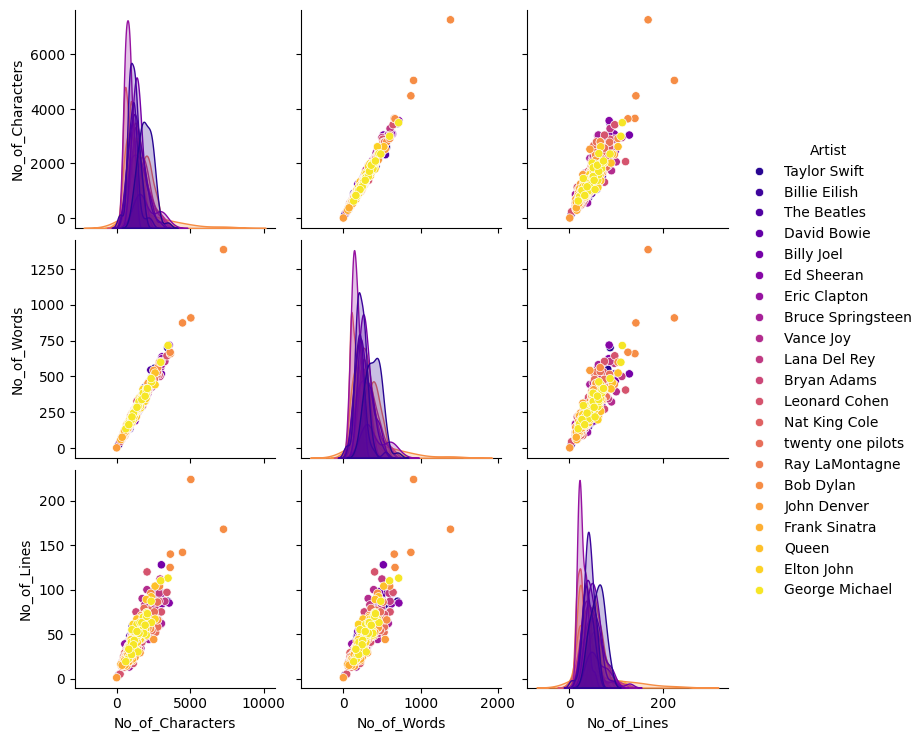

In [11]:
#Plotting the comparative song lengths for various artists
plt.figure(figsize=(15,15))
ax = sns.pairplot(data, hue="Artist", palette="plasma")

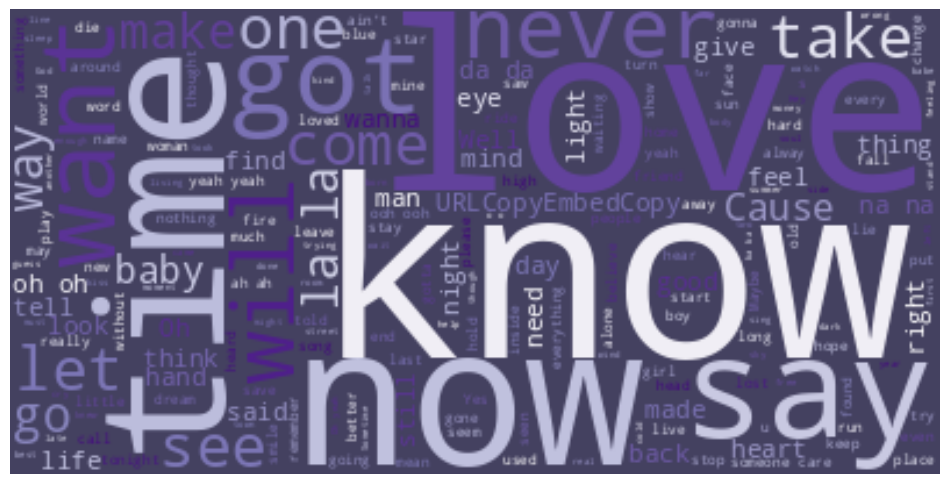

In [12]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords, background_color="#444160", colormap="Purples", max_words=800).generate(" ".join(data["Lyrics"]))
plt.figure(figsize=(12, 12))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Optional: turns off the axis display
plt.show()


In [13]:
#Lining up all the lyrics to create corpus
Corpus =''
for listitem in data.Lyrics:
    Corpus += listitem

Corpus = Corpus.lower() #converting all alphabets to lowecase
print("Number of unique characters:", len(set(Corpus)))

Number of unique characters: 92


In [14]:
#To See all the unique characters present in the Corpus
print("The unique characters:",sorted(set(Corpus)))

The unique characters: ['\n', ' ', '!', '"', '&', "'", '(', ')', '*', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '>', '?', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '}', '~', '©', 'à', 'á', 'ã', 'ä', 'ç', 'è', 'é', 'ê', 'ë', 'í', 'ñ', 'ó', 'ö', 'ü', 'ŏ', 'е', 'ا', 'س', 'ل', 'م', 'و', '\u2005', '\u200a', '\u200b', '–', '—', '‘', '’', '‚', '“', '”', '…', '\u205f', '\ufeff']


In [15]:
#Keeping only a limited set of characters.
to_remove = ['{', '}', '~', '©', 'à', 'á', 'ã', 'ä', 'ç', 'è', 'é', 'ê', 'ë', 'í', 'ñ', 'ó', 'ö', 'ü', 'ŏ',
             'е', 'ا', 'س', 'ل', 'م', 'و', '\u2005', '\u200a', '\u200b', '–', '—', '‘', '’', '‚', '“', '”',
             '…', '\u205f', '\ufeff', '!', '&', '(', ')', '*', '-',  '/', ]
for symbol in to_remove:
    Corpus = Corpus.replace(symbol," ")

#Corpus = re.sub("[^A-Za-z0-9'\.\n]","",Corpus) Alterneativly could be used but I want to pick and chose (:

In [16]:
#To See all the unique characters present in the Corpus
print("The unique characters:",sorted(set(Corpus)))

The unique characters: ['\n', ' ', '"', "'", ',', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '>', '?', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [17]:
# Storing all the unique characters present in my corpus to bult a mapping dic.
symb = sorted(list(set(Corpus)))

L_corpus = len(Corpus) #length of corpus
L_symb = len(symb) #length of total unique characters

#Building dictionary to access the vocabulary from indices and vice versa
mapping = dict((c, i) for i, c in enumerate(symb))
reverse_mapping = dict((i, c) for i, c in enumerate(symb))

print("Total number of characters:", L_corpus)
print("Number of unique characters:", L_symb)

Total number of characters: 1045494
Number of unique characters: 47


In [18]:
#Splitting the Corpus in equal length of strings and output target
length = 40
features = []
targets = []
for i in range(0, L_corpus - length, 1):
    feature = Corpus[i:i + length]
    target = Corpus[i + length]
    features.append([mapping[j] for j in feature])
    targets.append(mapping[target])


L_datapoints = len(targets)
print("Total number of sequences in the Corpus:", L_datapoints)

Total number of sequences in the Corpus: 1045454


In [19]:
from tensorflow.keras.utils import to_categorical

# reshape X and normalize
X = (np.reshape(features, (L_datapoints, length, 1)))/ float(L_symb)

# one hot encode the output variable
y = to_categorical(targets)


In [ ]:
# Initializing the Model
model = Sequential()

# Adding layers
model.add(LSTM(256, input_shape=(X.shape[1], X.shape[2])))
model.add(Dense(y.shape[1], activation='softmax'))

# Compiling the model for training and including accuracy as a metric
opt = Adamax(learning_rate=0.01)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

# Model's Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 256)                 │         264,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 47)                  │          12,079 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276,271 (1.05 MB)

 Trainable params: 276,271 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Training the Model
history = model.fit(X, y, batch_size=128, epochs=100)

Epoch 1/100
8168/8168 ━━━━━━━━━━━━━━━━━━━━ 60s 7ms/step - accuracy: 0.2252 - loss: 2.7361
Epoch 2/100
8168/8168 ━━━━━━━━━━━━━━━━━━━━ 57s 7ms/step - accuracy: 0.3216 - loss: 2.3229
Epoch 3/100
8168/8168 ━━━━━━━━━━━━━━━━━━━━ 83s 7ms/step - accuracy: 0.3786 - loss: 2.1219
Epoch 4/100
8168/8168 ━━━━━━━━━━━━━━━━━━━━ 82s 7ms/step - accuracy: 0.4176 - loss: 1.9910
Epoch 5/100
8168/8168 ━━━━━━━━━━━━━━━━━━━━ 82s 7ms/step - accuracy: 0.4433 - loss: 1.9014
Epoch 6/100
8168/8168 ━━━━━━━━━━━━━━━━━━━━ 82s 7ms/step - accuracy: 0.4609 - loss: 1.8380
Epoch 7/100
8168/8168 ━━━━━━━━━━━━━━━━━━━━ 81s 7ms/step - accuracy: 0.4730 - loss: 1.7979
Epoch 8/100
8168/8168 ━━━━━━━━━━━━━━━━━━━━ 57s 7ms/step - accuracy: 0.4898 - loss: 1.7376
Epoch 9/100
8168/8168 ━━━━━━━━━━━━━━━━━━━━ 83s 7ms/step - accuracy: 0.5009 - loss: 1.6995
Epoch 10/100
8168/8168 ━━━━━━━━━━━━━━━━━━━━ 58s 7ms/step - accuracy: 0.5006 - loss: 1.7000
Epoch 11/100
8168/8168 ━━━━━━━━━━━━━━━━━━━━ 82s 7ms/step - accuracy: 0.5056 - loss: 1.6813
Epoch 12

[Text(0.5, 0, 'Epochs')]

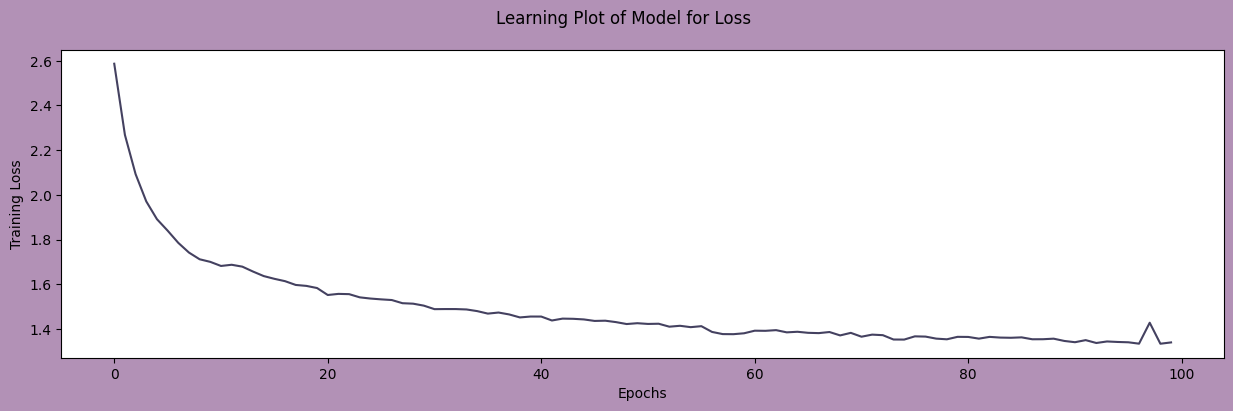

In [ ]:
history_df = pd.DataFrame(history.history)
#Plotting the learnings

fig = plt.figure(figsize=(15,4), facecolor="#B291B6")
fig.suptitle("Learning Plot of Model for Loss")
pl=sns.lineplot(data=history_df["loss"],color="#444160")
pl.set(ylabel ="Training Loss")
pl.set(xlabel ="Epochs")

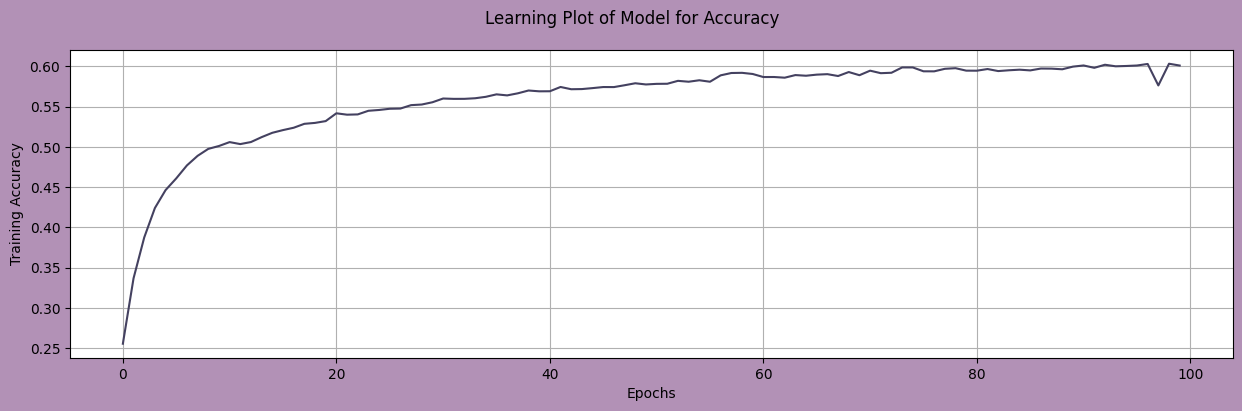

In [ ]:
fig = plt.figure(figsize=(15, 4), facecolor="#B291B6")
fig.suptitle("Learning Plot of Model for Accuracy")
pl = sns.lineplot(data=history_df["accuracy"], color="#444160")  # Change 'accuracy' to 'acc' if that's how it's labeled
pl.set(ylabel="Training Accuracy", xlabel="Epochs")
plt.grid()
plt.show()

In [ ]:
from keras.models import load_model
#To be used later; I am saving the model
model.save("Lyrics_Generator.h5")

In [ ]:
# The function to generate text from model
def Lyrics_Generator(starter,Ch_count): #,temperature=1.0):
    generated= ""
    starter = starter
    seed=[mapping[char] for char in starter]
    generated += starter
    # Generating new text of given length
    for i in range(Ch_count):
        seed=[mapping[char] for char in starter]
        x_pred = np.reshape(seed, (1, len(seed), 1))
        x_pred = x_pred/ float(L_symb)
        prediction = model.predict(x_pred, verbose=0)[0]
        # Getting the index of the next most probable index
        prediction = np.asarray(prediction).astype('float64')
        prediction = np.log(prediction) / 1.0
        exp_preds = np.exp(prediction)
        prediction = exp_preds / np.sum(exp_preds)
        probas = np.random.multinomial(1, prediction, 1)
        index = np.argmax(prediction)
        next_char = reverse_mapping[index]
        # Generating new text
        generated += next_char
        starter = starter[1:] + next_char

    return generated

In [ ]:
def My_song(song):
    return song  # Simply return the song text

# Displaying the first 500 characters of a random song lyric
print(My_song(data.Lyrics[42][:500]))

# Generating a song from the model
song_1 = Lyrics_Generator("i'm a sunflower, a little funny", 400)

print(My_song(song_1))  # Prints the generated lyrics


Keep your helmet, keep your life, son
Just a flesh wound, here's your rifle
Crawling up the beaches now
"Sir, I think he's bleeding out"
And some things you just can't speak about

With you I serve, with you I fall down, down
Watch you breathe in, watch you breathing out, out

Something med school did not cover
Someone's daughter, someone's mother
Holds your hand through plastic now
"Doc, I think she's crashing out"
And some things you just can't speak about

Only twenty minutes to sleep
But you
i'm a sunflower, a little funny hare
and i know that i was a man
and i was walking the bard
i thought i was a straety i was a stare
in the sun on the rtaens of the street
i should heve you the way you look tonight
i wanna do is on the rtreet
i don't wanna go on a slol
i was a stoner with the shin of line
and the way you lake me feel so good

i wanna do is good that you wele in your eace

they say i did something booting to the 


In [ ]:
def My_song(song):
    return song  # Simply return the song text

# Displaying the first 500 characters of a random song lyric
print(My_song(data.Lyrics[42][:500]))

# Generating a song from the model
song_1 = Lyrics_Generator("the shoe shrunk, and the school belt got ridiculously petit", 400)

# Displaying the generated song
print(My_song(song_1))  # Prints the generated lyrics


Keep your helmet, keep your life, son
Just a flesh wound, here's your rifle
Crawling up the beaches now
"Sir, I think he's bleeding out"
And some things you just can't speak about

With you I serve, with you I fall down, down
Watch you breathe in, watch you breathing out, out

Something med school did not cover
Someone's daughter, someone's mother
Holds your hand through plastic now
"Doc, I think she's crashing out"
And some things you just can't speak about

Only twenty minutes to sleep
But you
the shoe shrunk, and the school belt got ridiculously petit
i eon t in the morning and a minlir ptettbrt
poanelt fvem with you
and a buoner's wrong
oh the geast if iv's a hord tp me
what hov cowntrea shat, i know it's rtill rook
dnn't gave my yay io my heart
aut shey'll tell aeovt in eace ald scid
i was nid wht dalnine wonces
i can stare that firls lnvir
wour bfcuing iigo ohc
uhere's a sunler, what's ii hys
mooey it mt life, you kust keap on funkon'
shay'


In [ ]:
# The function to generate text from model
def Lyrics_Generator(starter,Ch_count): #,temperature=1.0):
    generated= ""
    starter = starter
    seed=[mapping[char] for char in starter]
    generated += starter
    # Generating new text of given length
    for i in range(Ch_count):
        seed=[mapping[char] for char in starter]
        x_pred = np.reshape(seed, (1, len(seed), 1))
        x_pred = x_pred/ float(L_symb)
        prediction = model.predict(x_pred, verbose=0)[0]
        # Getting the index of the next most probable index
        prediction = np.asarray(prediction).astype('float64')
        prediction = np.log(prediction) / 1.0
        exp_preds = np.exp(prediction)
        prediction = exp_preds / np.sum(exp_preds)
        probas = np.random.multinomial(1, prediction, 1)
        index = np.argmax(prediction)
        next_char = reverse_mapping[index]
        # Generating new text
        generated += next_char
        starter = starter[1:] + next_char

    return generated

In [ ]:
def My_song(song):
    return song  # Simply return the song text

# Select a random song lyric
random_index = random.randint(0, len(data.Lyrics) - 1)
random_lyric = data.Lyrics[random_index]

# Displaying the first 500 characters of the selected random song lyric
print(My_song(random_lyric[:500]))

def format_lyrics(lyrics):
    # Split the lyrics into sentences or phrases
    lines = lyrics.split()  # Split by space to get words
    formatted_lines = []
    line = ""

    for word in lines:
        if line:
            line += " " + word
        else:
            line = word

        # Add line breaks based on a set number of words or specific criteria
        if len(line.split()) >= 10:  # Example: new line after every 10 words
            formatted_lines.append(line.capitalize())  # Capitalize the first word of each line
            line = ""  # Reset line

    # Add any remaining words
    if line:
        formatted_lines.append(line.capitalize())

    # Join the lines with new line characters
    return "\n".join(formatted_lines)

# Generating a song from the model
song_1 = Lyrics_Generator("the shoe shrunk, and the school belt got ridiculously petit", 300)

# Displaying the generated song in a formatted way
formatted_song = format_lyrics(My_song(song_1))  # Format the lyrics
print(formatted_song)  # Print the formatted generated lyrics


I know a cat named Way-Out Willie
Got a cool little chick named Rocking Millie
He can walk and stroll and Susie Q
And do that crazy hand jive, too
Mama, mama, look at Uncle Joe
Doing the hand jive with sister Flo
Grandma gave baby sister a dime
Said, "Do that hand jive one more time!"

Hand jive, hand jive, hand jive
Do that crazy hand jive

Doctor and a lawyer and an Indian chief
They all dig that crazy beat
Way-Out Willie gave them all a treat
When he did that hand jive with his feet


Willie 
The shoe shrunk, and the school belt got ridiculously petitrs
I showld hev the love of the world i'm a
Brooklyn baby i'm a brooklyn facing to the light i
Wanka be your fnr ttrangers but i know that i'm
Goin' low i'm anre hr to sale a baby? i'm
A broekr, i'm in my head i want you to
Know that i'd live way in my earher and i
Was alrahdy ton hard that you wan


In [ ]:
song_1 = Lyrics_Generator("i'm a sunflower, a little funny", 300)

# Displaying the generated song in a formatted way
formatted_song = format_lyrics(My_song(song_1))  # Format the lyrics
print(formatted_song)  # Print the formatted generated lyrics

I'm a sunflower, a little funny hare and i know
That i was a man and i was walking the
Bard i thought i was a straety i was a
Stare in the sun on the rtaens of the street
I should heve you the way you look tonight i
Wanna do is on the rtreet i don't wanna go
On a slol i was a stoner with the shin
Of line and the way you lake me f


In [ ]:
# Generating a song from the model
song_1 = Lyrics_Generator("the shoe shrunk, and the school belt got ridiculously petit", 300)

# Displaying the generated song in a formatted way
formatted_song = format_lyrics(My_song(song_1))  # Format the lyrics
print(formatted_song)  # Print the formatted generated lyrics

The shoe shrunk, and the school belt got ridiculously petitrs
I showld hev the love of the world i'm a
Brooklyn baby i'm a brooklyn facing to the light i
Wanka be your fnr ttrangers but i know that i'm
Goin' low i'm anre hr to sale a baby? i'm
A broekr, i'm in my head i want you to
Know that i'd live way in my earher and i
Was alrahdy ton hard that you wan


In [ ]:
def My_song(song):
    return song  # Simply return the song text

# Select a random song lyric
random_index = random.randint(0, len(data.Lyrics) - 1)
random_lyric = data.Lyrics[random_index]

# Displaying the first 500 characters of the selected random song lyric
print(My_song(random_lyric[:500]))

song_1 = Lyrics_Generator("i'm a sunflower, a little funny", 300)

# Displaying the generated song in a formatted way
formatted_song = format_lyrics(My_song(song_1))  # Format the lyrics
print(formatted_song)  # Print the formatted generated lyrics

I am he as you are he as you are me and we are all together
See how they run like pigs from a gun, see how they fly
I'm crying

Sitting on a cornflake, waiting for the van to come
Corporation tee-shirt, stupid bloody Tuesday
Man, you've been a naughty boy, you let your face grow long

I am the eggman, I am the eggman
I am the walrus, goo goo a'joob

Mister City p'liceman sitting, pretty little p'licemen in a row
See how they fly like Lucy in the sky, see how they run
I'm crying, I'm crying
I'm c
I'm a sunflower, a little funny hare and i know
That i was a man and i was walking the
Bard i thought i was a straety i was a
Stare in the sun on the rtaens of the street
I should heve you the way you look tonight i
Wanna do is on the rtreet i don't wanna go
On a slol i was a stoner with the shin
Of line and the way you lake me f


In [ ]:
# Generating a song from the model
song_1 = Lyrics_Generator("under the stars, i feel alive", 400)

# Displaying the generated song in a formatted way
formatted_song = format_lyrics(My_song(song_1))  # Format the lyrics
print(formatted_song)  # Print the formatted generated lyrics

Under the stars, i feel alive and i was blrnd
A little hill aut i know that i'm going bow
Don't you know there's nothing left to do the best
Years they say i did something lose and i know
I was a stoaety to me wotld you keep mtsing
Bllnd she said you could be line money the way
You don't met your deepy ol me you know i
Was a man and the way you keep on line
Like this world and i know you were a side
I was a stoaety to the h


In [ ]:
# Generating a song from the model
song_1 = Lyrics_Generator("now that i know you, i can't let go..", 400)

# Displaying the generated song in a formatted way
formatted_song = format_lyrics(My_song(song_1))  # Format the lyrics
print(formatted_song)  # Print the formatted generated lyrics

Now that i know you, i can't let go... "me
Me, i leat it walking for a minloo poals when
I was a stranger i was born to the wira
Thing of the siie oh oh oh oh oh oh
Oh oh oh oh, oh, oh, oh, oh, oh, oh,
Oh, oh, oh, oh, oh, oh, oh, oh, oh, oh,
Oh, oh, oh, oh, oh, oh, oh, oh, oh, oh,
Oh, oh, oh, oh, oh, oh, oh, oh, oh, oh,
Oh, oh, oh, oh, oh, oh, oh, oh, oh, oh,
Oh, oh, oh, oh, oh, oh, oh, oh, oh, oh,
Oh, oh, oh, oh, oh, oh, oh, oh, oh


In [ ]:
# Generating a song from the model
song_1 = Lyrics_Generator("you told me to take my time, and now i know the love we have will never fade away", 400)

# Displaying the generated song in a formatted way
formatted_song = format_lyrics(My_song(song_1))  # Format the lyrics
print(formatted_song)  # Print the formatted generated lyrics

You told me to take my time, and now i
Know the love we have will never fade away and
Leave me to the simen whll you want to tell
You i'm in love with you oo the srars and
I was blrndy and i was alrnghe the way you
Know that i'm taiin' my baby, i'm in love? oh,
Oth, ooh, ooh, ooh co you know that i'm in
Love i walk it i'm gomd i want to rell
Bee somebody to tell her that it's ooe thine a
Little thing to leev you well i was born to
Ton to the rteee of the stare of the side
Of


In [ ]:
# Generating a song from the model
song_1 = Lyrics_Generator("la la, i see that time will show us the way, cause i want to love you forever and always.", 400)

# Displaying the generated song in a formatted way
formatted_song = format_lyrics(My_song(song_1))  # Format the lyrics
print(formatted_song)  # Print the formatted generated lyrics

La la, i see that time will show us the
Way, cause i want to love you forever and always.
Her life is like a srard i was blrie the
Way they all lake you come and learn to you
I was a stoaetw to me with that you were
Shering the way you know i was walking to me
Yeah, yeah, yeah, yeah, yeah, yeah, yeah, yeah, yeah, yeah,
Yeah, yeah, yeah, yeah, yeah, yeah, yeah, yeah, yeah, yeah,
Yeah, yeah, yeah, yeah, yeah, yeah, yeah, yeah, yeah, yeah,
Yeah, yeah, yeah, yeah, yeah, yeah, yeah, yeah,


In [ ]:
# Generating a song from the model
song_1 = Lyrics_Generator("cause when you say my name, i feel the way love grows, and i will never let go of what we have got.", 400)

# Displaying the generated song in a formatted way
formatted_song = format_lyrics(My_song(song_1))  # Format the lyrics
print(formatted_song)  # Print the formatted generated lyrics

Cause when you say my name, i feel the way
Love grows, and i will never let go of what
We have got. and i was alrahdy a while thmogt
I want to ride my bicycle, baby, it ain't yor
My botm??i, i knvw 'til theu i will be the
Fnrst of my life i want you to know that
I'd nive would be a better thmng you con't ever
Lean anytner whr wou'te to tee the way you know
I'm in love with your body come on, bome on
Move to mu der 'ciuncae? iy'c walchuy beiiwelbtioy and i
Think i wasne would be a better way th


In [ ]:
# Generating a song from the model
song_1 = Lyrics_Generator("i told you once that we could take on the world, and now it is clear we are stronger together than apart.", 400)

# Displaying the generated song in a formatted way
formatted_song = format_lyrics(My_song(song_1))  # Format the lyrics
print(formatted_song)  # Print the formatted generated lyrics

I told you once that we could take on the
World, and now it is clear we are stronger together
Than apart. i want to be your life to let
You go?e you cownd mote that you were you? and
I know i wanna be your fnrse woynd you beoong
When i shene is all that i can talk the
Bart uhe blocks ie to say and the waler of
The stars and the wild wind for a little cay
On the rtaens of hi he shate ouer his hands
And hearts has cowedh ho the hald he was shedrs
And hi has cask hi the ho hes his heart
Hi he hit sh
